In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('bank.csv', sep=';', encoding="ISO-8859-1")

In [3]:
# Set a style for seaborn plots
sns.set_style("whitegrid")

In [4]:
# Scatter plot: Age vs Balance

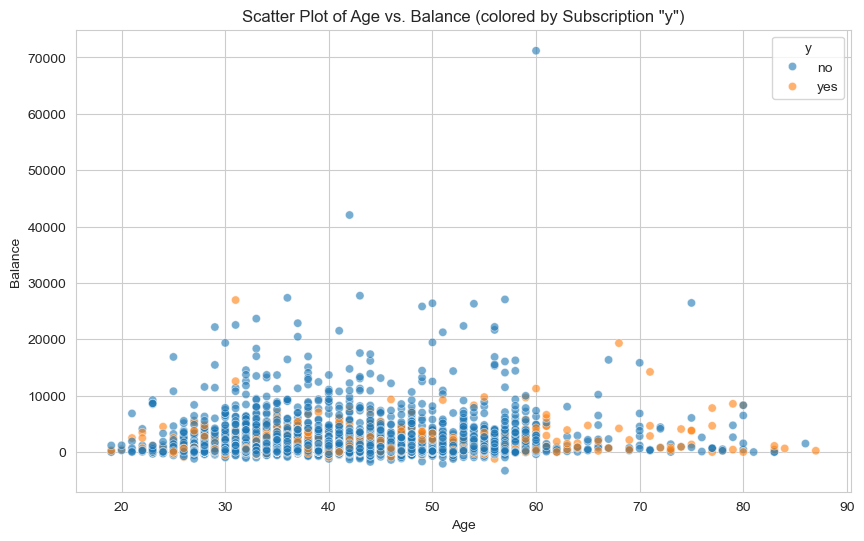

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=df, hue='y', alpha=0.6)
plt.title('Scatter Plot of Age vs. Balance (colored by Subscription "y")')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()


In [6]:
# Scatter plot: Duration vs Campaign contacts

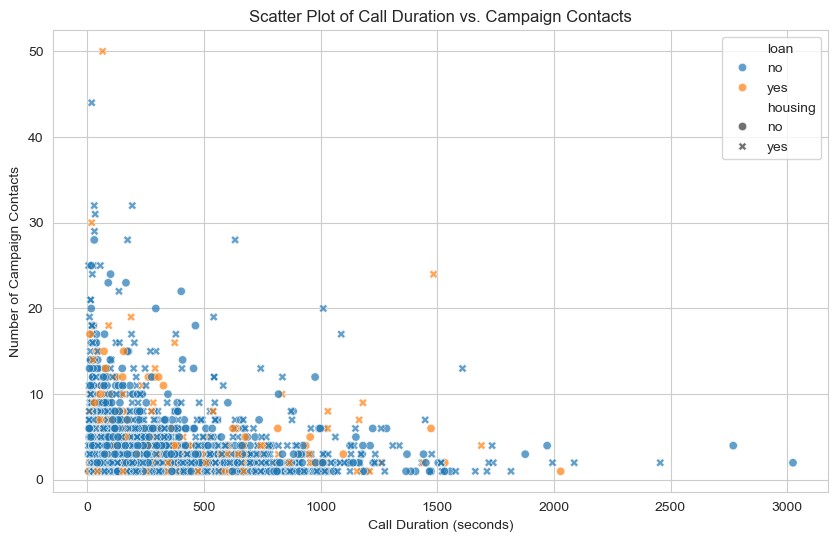

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='campaign', data=df, hue='loan', style='housing', alpha=0.7)
plt.title('Scatter Plot of Call Duration vs. Campaign Contacts')
plt.xlabel('Call Duration (seconds)')
plt.ylabel('Number of Campaign Contacts')
plt.show()

## 3. Line Plot

Line plots are typically used to show trends over a continuous interval or time.
For this dataset, we can group by a variable (e.g., `age`) and plot an aggregate (e.g., mean `balance`).

*   **`matplotlib.pyplot.plot()`**
*   **`seaborn.lineplot()`**

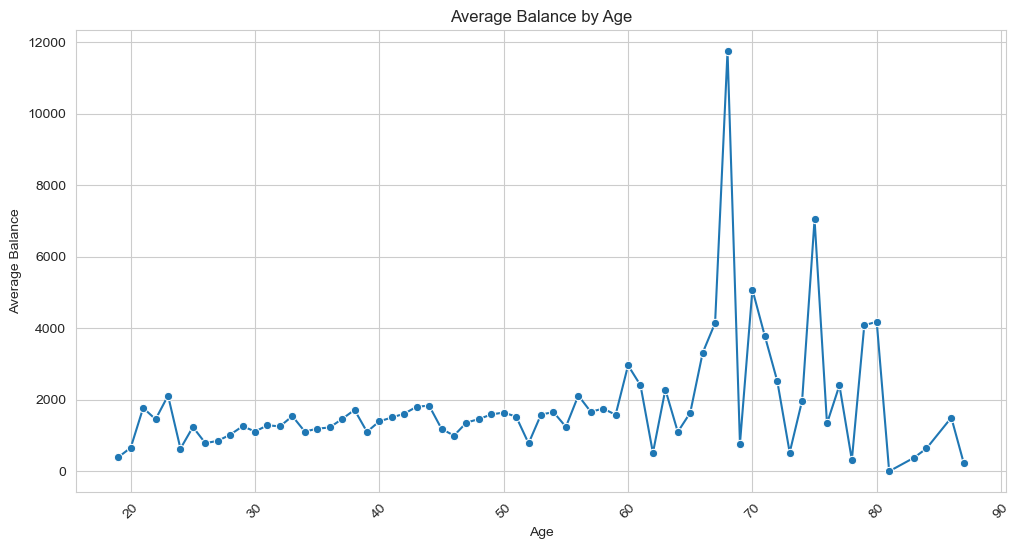

In [8]:
age_balance = df.groupby('age')['balance'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='balance', data=age_balance, marker='o')
plt.title('Average Balance by Age')
plt.xlabel('Age')
plt.ylabel('Average Balance')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

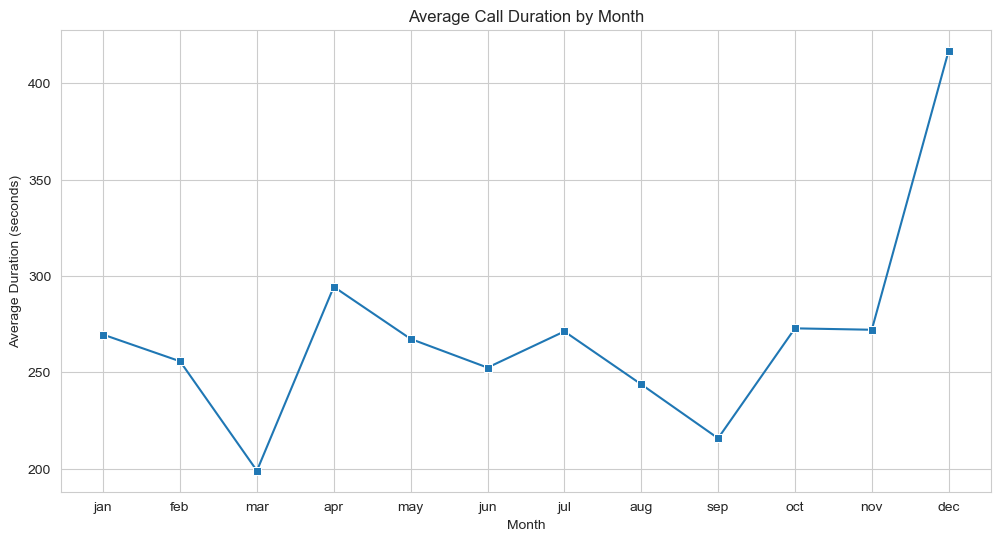

In [9]:
#Line plot: Average duration by month (requires ordering months)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
if 'month_cat' not in df.columns: # Ensure this column is created for the groupby
    df['month_cat'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

month_duration = df.groupby('month_cat', observed=True)['duration'].mean().reset_index() # added observed=True for robustness with categoricals

plt.figure(figsize=(12, 6))
# CORRECTED LINE: Removed group=1
sns.lineplot(x='month_cat', y='duration', data=month_duration, marker='s')
plt.title('Average Call Duration by Month')
plt.xlabel('Month')
plt.ylabel('Average Duration (seconds)')
plt.show()

## 4. Histogram (Histplot)

Histograms show the distribution of a single numerical variable by dividing the data into bins and counting the number of observations in each bin.

*   **`matplotlib.pyplot.hist()`**
*   **`seaborn.histplot()`** (more flexible, can do KDE)
*   **`DataFrame.plot(kind='hist')`**

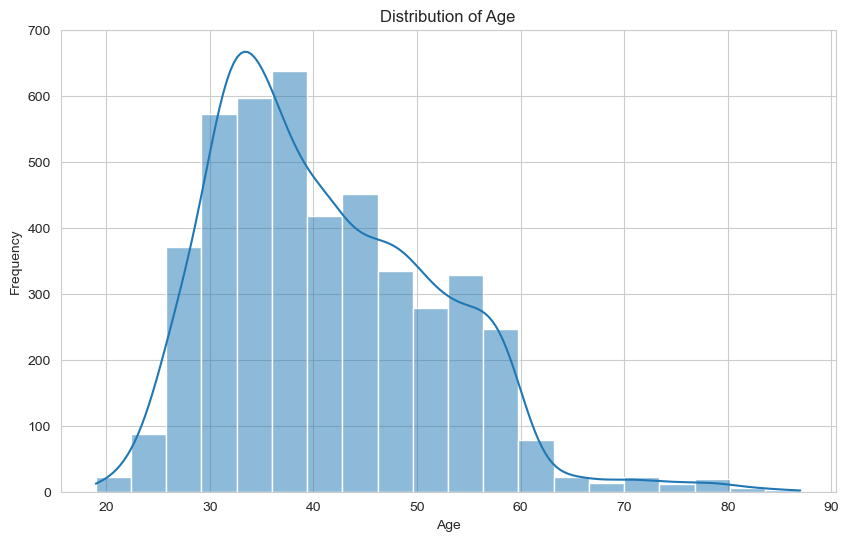

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True) # kde adds a density curve
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


## 5. Bar Plot

Bar plots are used to compare a numerical value (e.g., mean, count) across different categories.

*   **`matplotlib.pyplot.bar()`**
*   **`seaborn.barplot()`** (shows mean and confidence interval by default)
*   **`seaborn.countplot()`** (for counts of categories)
*   **`DataFrame.plot(kind='bar')`**

C:\Users\qli97\AppData\Local\Temp\ipykernel_59456\2289437546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='job', data=df, order = df['job'].value_counts().index, palette='viridis')


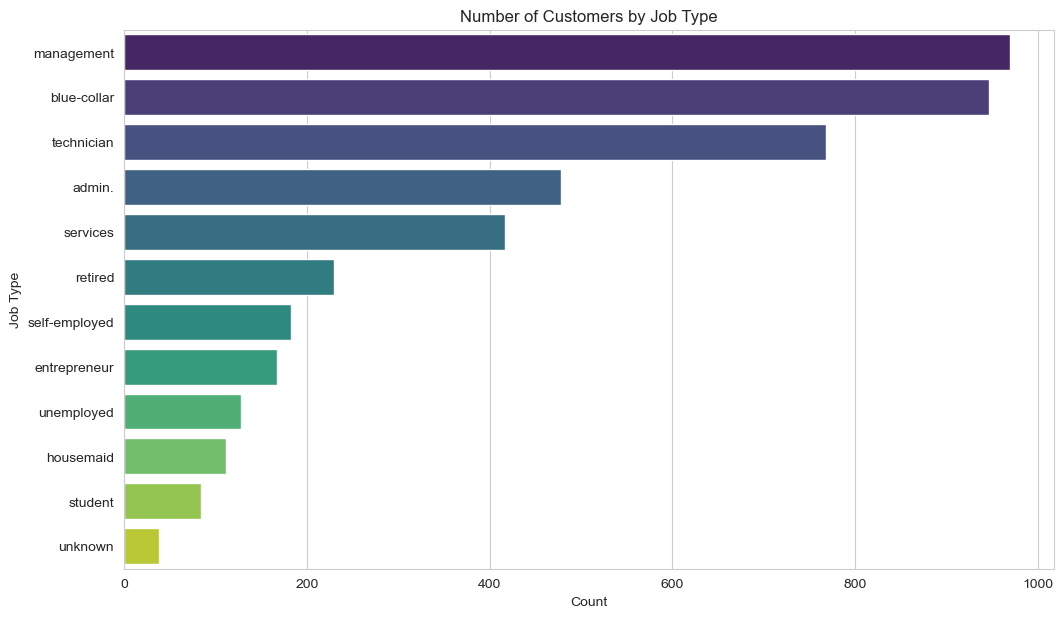

In [11]:
# Bar Plot: Counts of each Job type (using seaborn.countplot)
plt.figure(figsize=(12, 7))
sns.countplot(y='job', data=df, order = df['job'].value_counts().index, palette='viridis')
plt.title('Number of Customers by Job Type')
plt.xlabel('Count')
plt.ylabel('Job Type')
plt.show()


C:\Users\qli97\AppData\Local\Temp\ipykernel_59456\1500632330.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='education', y='balance', data=df, order=['primary', 'secondary', 'tertiary', 'unknown'], palette='magma', ci='sd') # ci='sd' for std dev
C:\Users\qli97\AppData\Local\Temp\ipykernel_59456\1500632330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='education', y='balance', data=df, order=['primary', 'secondary', 'tertiary', 'unknown'], palette='magma', ci='sd') # ci='sd' for std dev


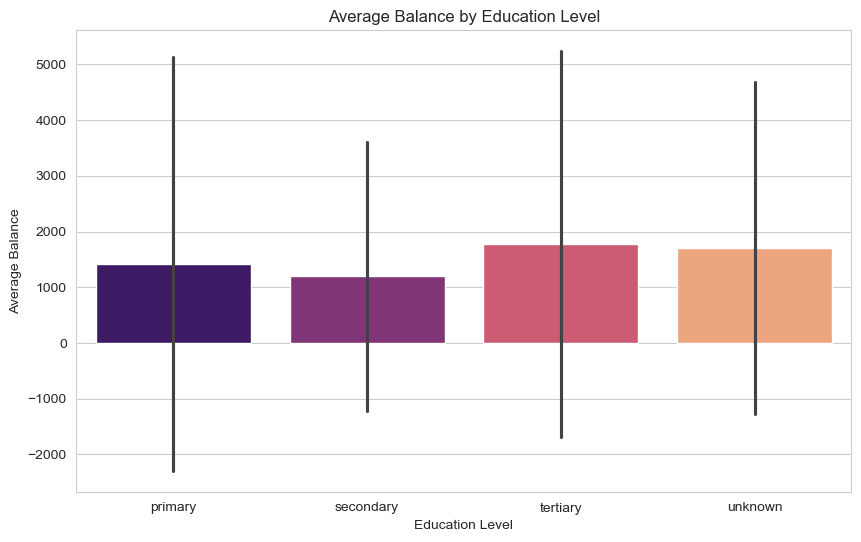

In [12]:
# Bar Plot: Average balance by Education level (using seaborn.barplot)
plt.figure(figsize=(10, 6))
sns.barplot(x='education', y='balance', data=df, order=['primary', 'secondary', 'tertiary', 'unknown'], palette='magma', ci='sd') # ci='sd' for std dev
plt.title('Average Balance by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Balance')
plt.show()

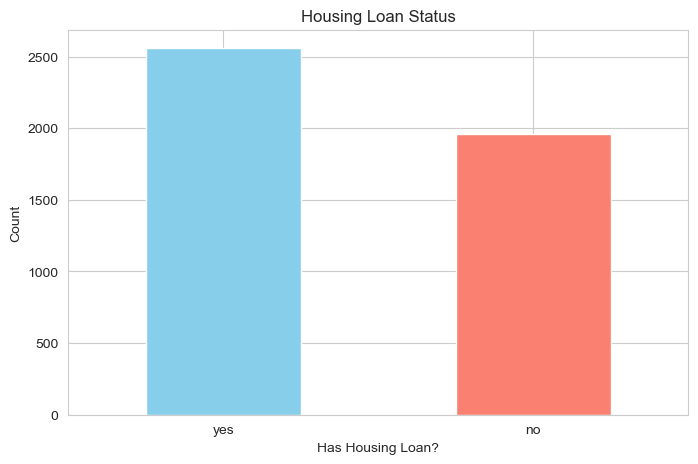

In [13]:
# Bar Plot: Number of 'yes' and 'no' for housing loan (using pandas)
df['housing'].value_counts().plot(kind='bar', figsize=(8,5), color=['skyblue', 'salmon'])
plt.title('Housing Loan Status')
plt.xlabel('Has Housing Loan?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

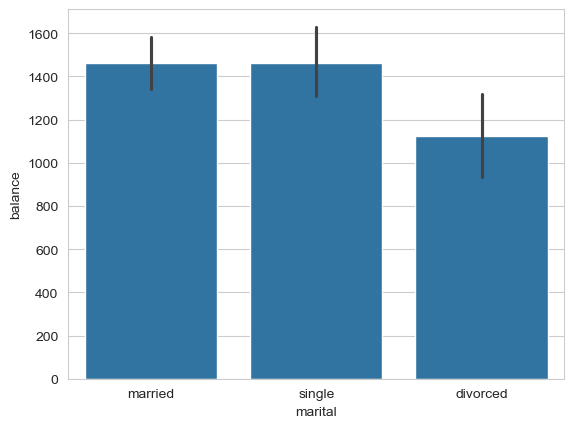

In [14]:
sns.barplot(x='marital',y='balance',data=df)

plt.xticks(rotation=0)
plt.show()

## 6. Stacked Bar Plot

Stacked bar plots are used to show the composition of categories within another category. For example, the distribution of marital status for each job type.

*   **`DataFrame.plot(kind='bar', stacked=True)`** (easiest after preparing data with `groupby` or `crosstab`)

Crosstab for Education vs Marital:
 marital    divorced  married  single
education                           
primary          79      526      73
secondary       270     1427     609
tertiary        155      727     468
unknown          24      117      46


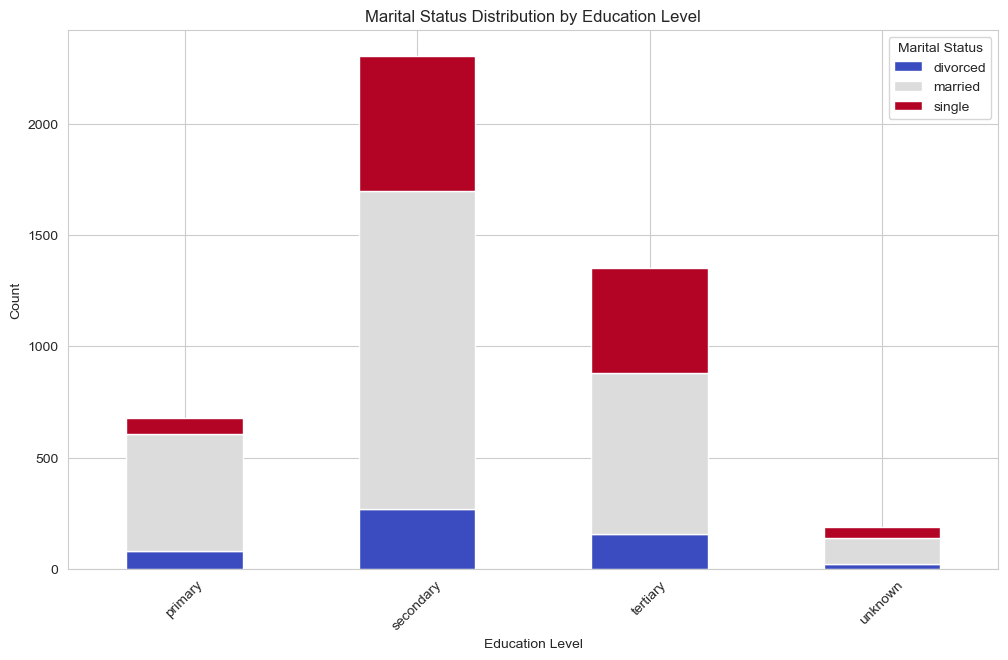

In [15]:
# Stacked Bar Plot: Marital status distribution for each Education level
# First, create a cross-tabulation
edu_marital_ct = pd.crosstab(df['education'], df['marital'])
print("Crosstab for Education vs Marital:\n", edu_marital_ct)

edu_marital_ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='coolwarm')
plt.title('Marital Status Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Marital Status')
plt.show()


Crosstab for Poutcome vs Y:
 y           no  yes
poutcome           
failure    427   63
other      159   38
success     46   83
unknown   3368  337


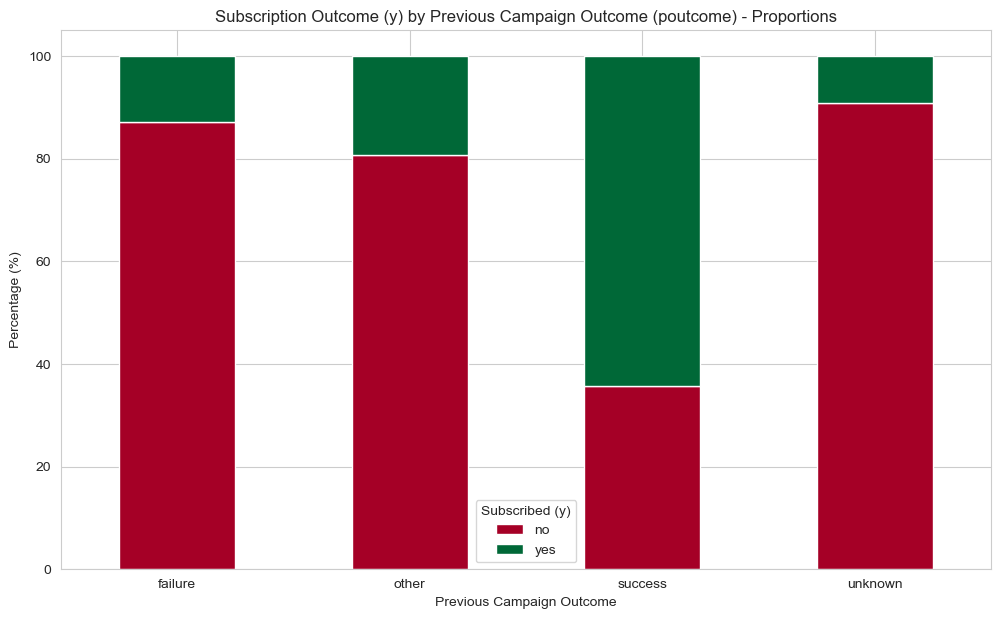

In [16]:
# Stacked Bar Plot: 'y' (subscription) outcome by 'poutcome' (previous campaign outcome)
outcome_y_ct = pd.crosstab(df['poutcome'], df['y'])
print("\nCrosstab for Poutcome vs Y:\n", outcome_y_ct)

# Normalize to show proportions (optional, but often more insightful)
outcome_y_ct_norm = outcome_y_ct.apply(lambda x: x / x.sum() * 100, axis=1)

outcome_y_ct_norm.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn')
plt.title('Subscription Outcome (y) by Previous Campaign Outcome (poutcome) - Proportions')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Subscribed (y)')
plt.show()

## 7. Pie Chart

Pie charts are used to show the proportion of categories of a single categorical variable. Best for a small number of categories.

*   **`matplotlib.pyplot.pie()`**
*   **`DataFrame['column'].value_counts().plot(kind='pie')`**

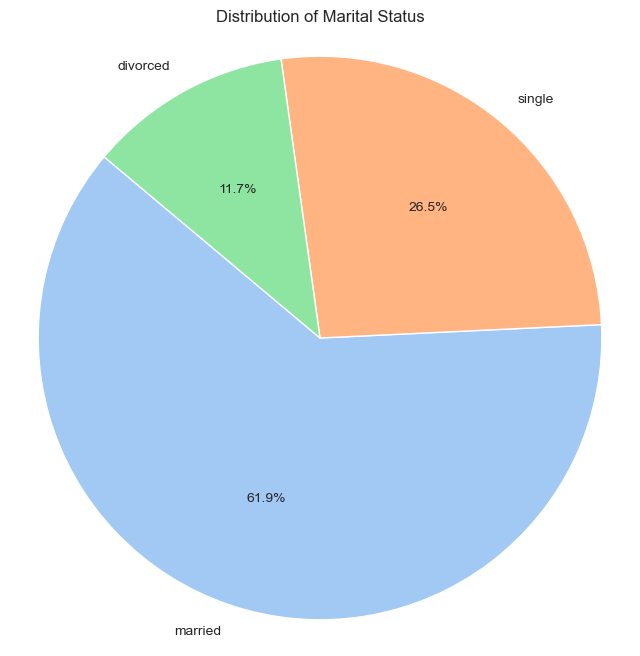

In [17]:
marital_counts = df['marital'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Marital Status')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

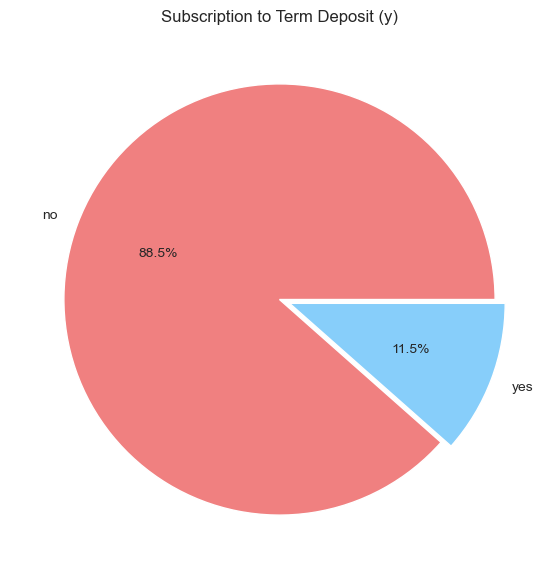

In [18]:
# Pie Chart: Distribution of Target Variable 'y' (using pandas plot)
df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7),
                             colors=['lightcoral', 'lightskyblue'], explode=(0, 0.05), # explode the 'yes' slice
                             title='Subscription to Term Deposit (y)')
plt.ylabel('') # Hide the 'y' label on the side
plt.show()

## 8. Box Plot

Box plots (or box-and-whisker plots) display the distribution of numerical data based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. They are useful for comparing distributions across categories.

*   **`matplotlib.pyplot.boxplot()`**
*   **`seaborn.boxplot()`**

C:\Users\qli97\AppData\Local\Temp\ipykernel_59456\3729564638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='marital', y='balance', data=df, palette='Set3')


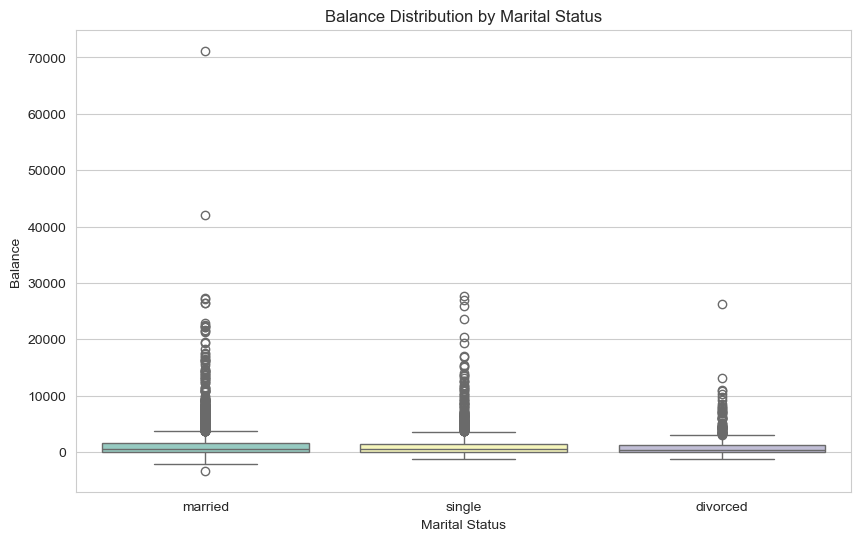

In [19]:
# Box Plot: Balance distribution by Marital status
plt.figure(figsize=(10, 6))
sns.boxplot(x='marital', y='balance', data=df, palette='Set3')
plt.title('Balance Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Balance')
# plt.ylim(-5000, 30000) # Optional: zoom in if outliers are too extreme
plt.show()

C:\Users\qli97\AppData\Local\Temp\ipykernel_59456\2043939970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='age', data=df, palette='PRGn')


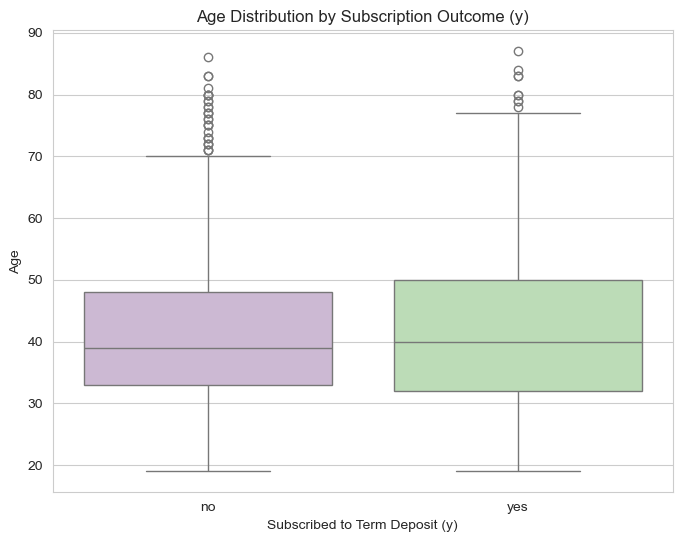

In [20]:
# Box Plot: Age distribution by subscription status 'y'
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='age', data=df, palette='PRGn')
plt.title('Age Distribution by Subscription Outcome (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Age')
plt.show()

## 9. Violin Plot

Violin plots are similar to box plots but also show the probability density of the data at different values (like a smoothed histogram). They are useful for visualizing the shape of the distribution.

*   **`seaborn.violinplot()`**

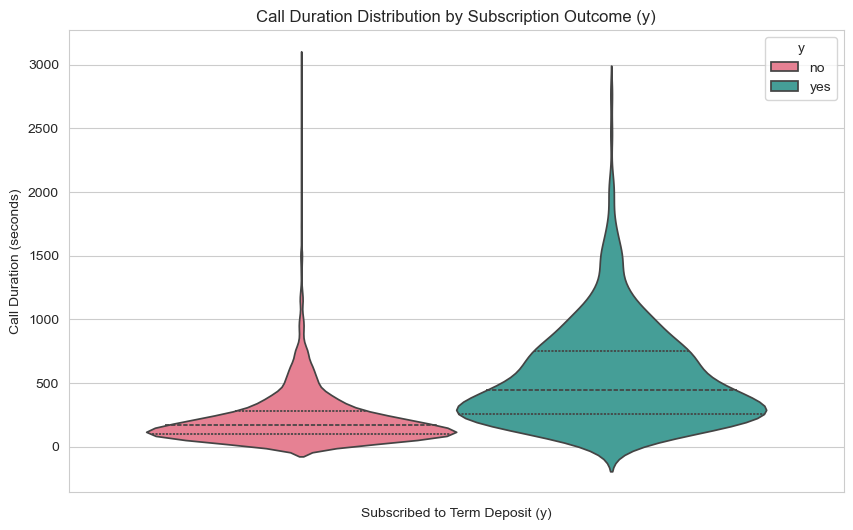

In [21]:
# Violin Plot: Duration distribution by subscription status 'y'
plt.figure(figsize=(10, 6))
sns.violinplot(hue='y', y='duration', data=df, palette='husl', inner='quartile') # inner can be 'box', 'quartile', 'point', 'stick', None
plt.title('Call Duration Distribution by Subscription Outcome (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Call Duration (seconds)')
# plt.ylim(0, 2000) # Optional: zoom in if outliers are too extreme
plt.show()

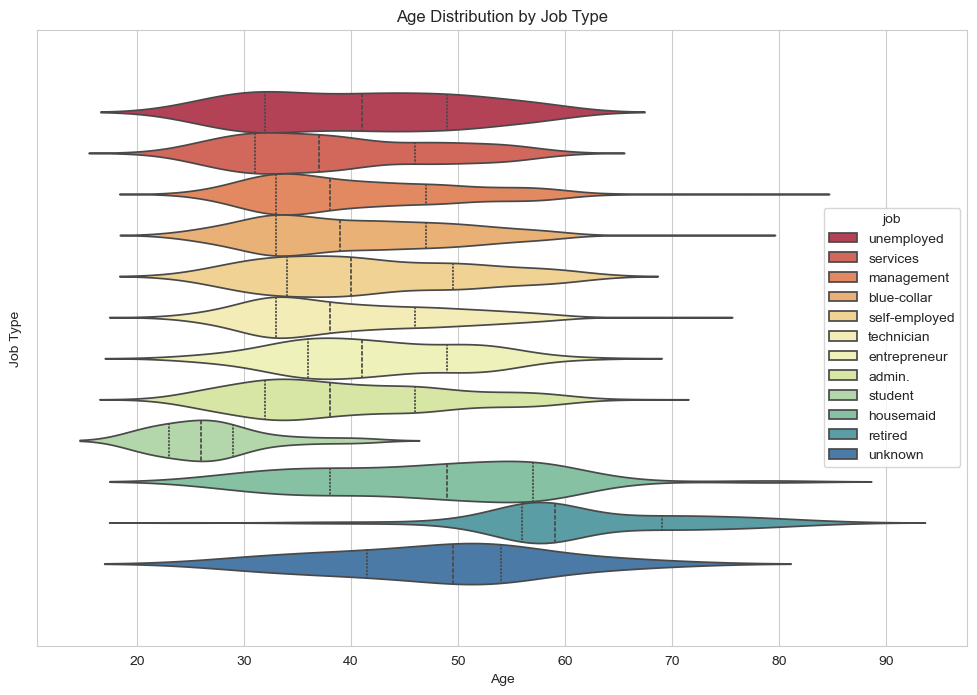

In [22]:
# Violin Plot: Age distribution by Job type (can get crowded, select fewer jobs or orient horizontally)
plt.figure(figsize=(12, 8))
# Sort jobs by median age for better presentation (optional)
# order = df.groupby('job')['age'].median().sort_values().index
sns.violinplot(x='age', hue='job', data=df, # order=order,
               palette='Spectral', inner='quartile', orient='h')
plt.title('Age Distribution by Job Type')
plt.xlabel('Age')
plt.ylabel('Job Type')
plt.show()

## 10. Heatmap (Bonus)

Heatmaps are useful for visualizing the correlation matrix of numerical features or for displaying 2D data like contingency tables.

*   **`seaborn.heatmap()`**

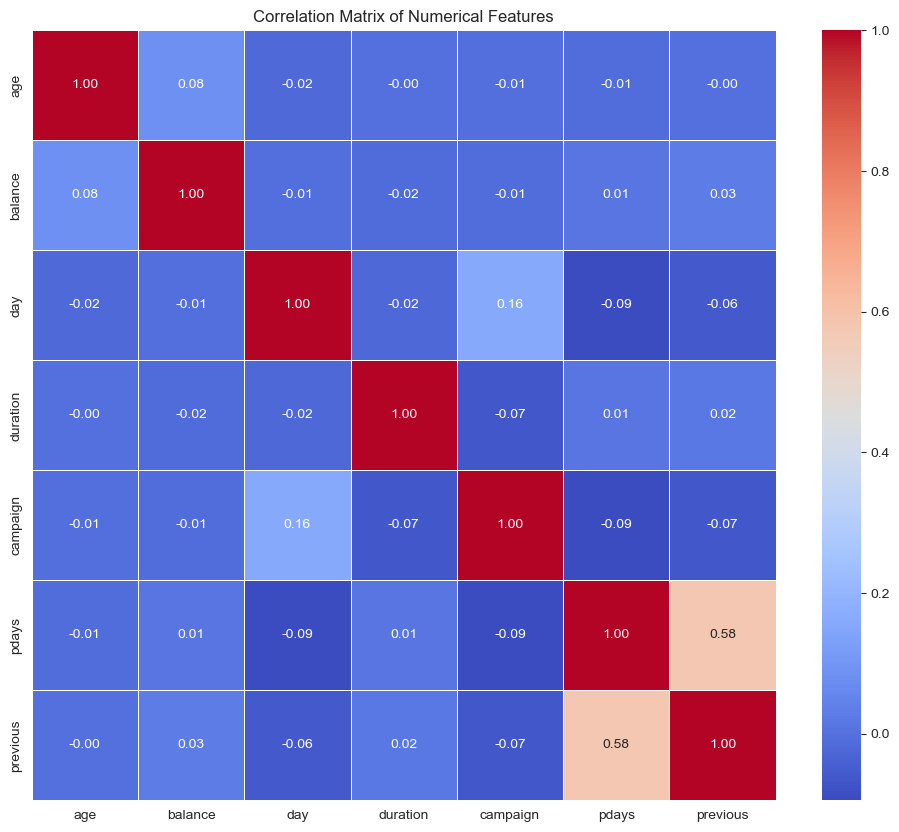

In [23]:
# Heatmap: Correlation matrix of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

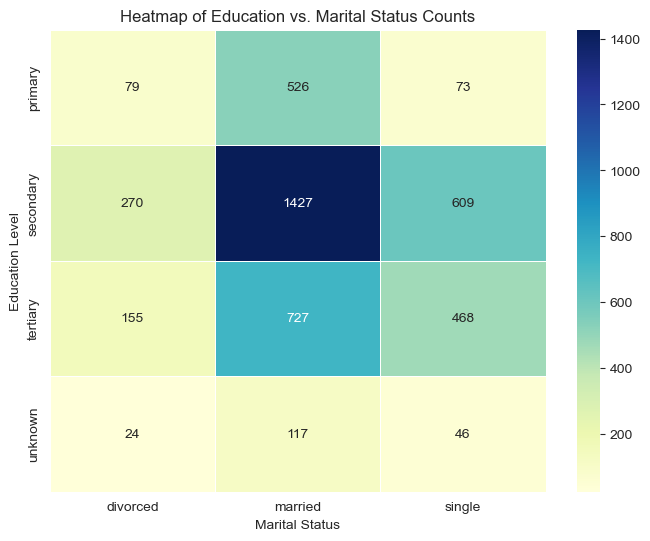

In [24]:
# Heatmap: Contingency table (from stacked bar plot example)
# edu_marital_ct was created earlier: pd.crosstab(df['education'], df['marital'])
plt.figure(figsize=(8, 6))
sns.heatmap(edu_marital_ct, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Education vs. Marital Status Counts')
plt.xlabel('Marital Status')
plt.ylabel('Education Level')
plt.show()